Find the RA and DEC cuts that reproduce the DESI North vs South boundary.

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
field = 'south'

lrg = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_{}_1.0.0_basic.fits'.format(field), columns=['TARGETID', 'RA', 'DEC']))
print(len(lrg))

9144035


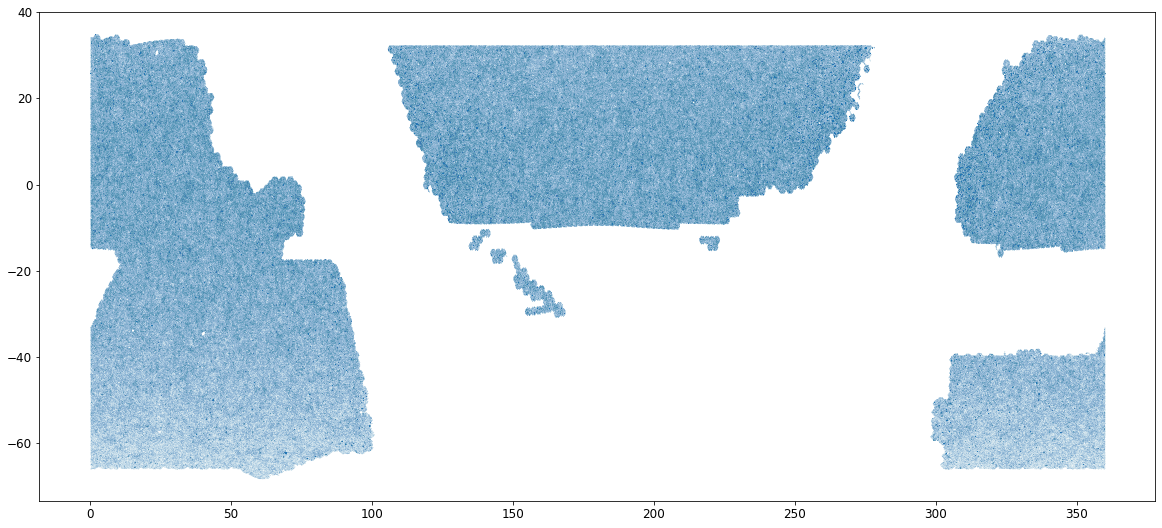

In [4]:
plt.figure(figsize=(20, 9))
plt.plot(lrg['RA'], lrg['DEC'], '.', ms=0.1, alpha=0.1)
plt.show()

In [5]:
columns = ['TARGETID', 'TYPE', 'RA', 'DEC', 'EBV',
'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FIBERFLUX_Z',
'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1',
'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1',
'GAIA_PHOT_G_MEAN_MAG', 'FIBERTOTFLUX_Z',
'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS']

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/lrg_xcorr/magnification/lrg_magnification_{}.fits'.format(field), columns=columns))

In [6]:
mask_quality = np.full(len(cat), True)

mask_quality &= (cat['FLUX_IVAR_R'] > 0) & (cat['FLUX_R'] > 0)   # ADM quality in r.
mask_quality &= (cat['FLUX_IVAR_Z'] > 0) & (cat['FLUX_Z'] > 0) & (cat['FIBERFLUX_Z'] > 0)   # ADM quality in z.
mask_quality &= (cat['FLUX_IVAR_W1'] > 0) & (cat['FLUX_W1'] > 0)  # ADM quality in W1.

mask_quality &= (cat['GAIA_PHOT_G_MEAN_MAG'] == 0) | (cat['GAIA_PHOT_G_MEAN_MAG'] > 18)  # remove bright GAIA sources

# ADM remove stars with zfibertot < 17.5 that are missing from GAIA.
mask_quality &= cat['FIBERTOTFLUX_Z'] < 10**(-0.4*(17.5-22.5))

# ADM observed in every band.
mask_quality &= (cat['NOBS_G'] > 0) & (cat['NOBS_R'] > 0) & (cat['NOBS_Z'] > 0)

# Apply masks
maskbits = [1, 12, 13]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
mask_quality &= mask_clean

gmag = 22.5 - 2.5 * np.log10((cat['FLUX_G'] / cat['MW_TRANSMISSION_G']).clip(1e-7))
# ADM safe as these fluxes are set to > 0 in notinLRG_mask.
rmag = 22.5 - 2.5 * np.log10((cat['FLUX_R'] / cat['MW_TRANSMISSION_R']).clip(1e-7))
zmag = 22.5 - 2.5 * np.log10((cat['FLUX_Z'] / cat['MW_TRANSMISSION_Z']).clip(1e-7))
w1mag = 22.5 - 2.5 * np.log10((cat['FLUX_W1'] / cat['MW_TRANSMISSION_W1']).clip(1e-7))
zfibermag = 22.5 - 2.5 * np.log10((cat['FIBERFLUX_Z'] / cat['MW_TRANSMISSION_Z']).clip(1e-7))

mask_lrg = np.full(len(cat), True)

if field=='south':
    mask_lrg &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
    mask_lrg &= zfibermag < 21.6                   # faint limit
    mask_lrg &= (gmag - w1mag > 2.9) | (rmag - w1mag > 1.8)  # low-z cuts
    mask_lrg &= (
        ((rmag - w1mag > (w1mag - 17.14) * 1.8)
         & (rmag - w1mag > (w1mag - 16.33) * 1.))
        | (rmag - w1mag > 3.3)
    )  # double sliding cuts and high-z extension
else:
    mask_lrg &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
    mask_lrg &= zfibermag < 21.61                   # faint limit
    mask_lrg &= (gmag - w1mag > 2.97) | (rmag - w1mag > 1.8)  # low-z cuts
    mask_lrg &= (
        ((rmag - w1mag > (w1mag - 17.13) * 1.83)
         & (rmag - w1mag > (w1mag - 16.31) * 1.))
        | (rmag - w1mag > 3.4)
    )  # double sliding cuts and high-z extension

mask_lrg &= mask_quality

0.0


In [7]:
cat = cat[mask_lrg]

mask = (cat['DEC']<=32.375) | (cat['RA']<104) | (cat['RA']>280)
cat = cat[mask]

In [8]:
print(len(lrg))
print(len(cat))

9144035
9144035


In [9]:
mask = np.in1d(cat['TARGETID'], lrg['TARGETID'])
print(np.sum(mask), np.sum(~mask))

mask = np.in1d(lrg['TARGETID'], cat['TARGETID'])
print(np.sum(mask), np.sum(~mask))

print(len(lrg))

9144034 1
9144034 1
9144035


The one missing LRG is due to numerical error in   
rmag - w1mag - (w1mag - 17.14) * 1.8

------

In [10]:
field = 'north'

lrg = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_{}_1.0.0_basic.fits'.format(field), columns=['TARGETID', 'RA', 'DEC']))
print(len(lrg))

3194955


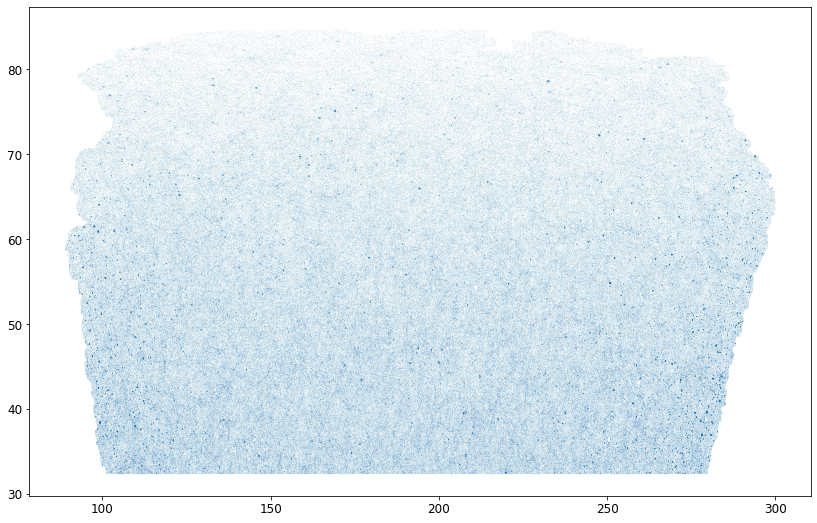

In [11]:
plt.figure(figsize=(14, 9))
plt.plot(lrg['RA'], lrg['DEC'], '.', ms=0.1, alpha=0.1)
plt.show()

In [12]:
columns = ['TARGETID', 'TYPE', 'RA', 'DEC', 'EBV',
'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FIBERFLUX_Z',
'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1',
'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1',
'GAIA_PHOT_G_MEAN_MAG', 'FIBERTOTFLUX_Z',
'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS']

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/lrg_xcorr/magnification/lrg_magnification_{}.fits'.format(field), columns=columns))

In [13]:
mask_quality = np.full(len(cat), True)

mask_quality &= (cat['FLUX_IVAR_R'] > 0) & (cat['FLUX_R'] > 0)   # ADM quality in r.
mask_quality &= (cat['FLUX_IVAR_Z'] > 0) & (cat['FLUX_Z'] > 0) & (cat['FIBERFLUX_Z'] > 0)   # ADM quality in z.
mask_quality &= (cat['FLUX_IVAR_W1'] > 0) & (cat['FLUX_W1'] > 0)  # ADM quality in W1.

mask_quality &= (cat['GAIA_PHOT_G_MEAN_MAG'] == 0) | (cat['GAIA_PHOT_G_MEAN_MAG'] > 18)  # remove bright GAIA sources

# ADM remove stars with zfibertot < 17.5 that are missing from GAIA.
mask_quality &= cat['FIBERTOTFLUX_Z'] < 10**(-0.4*(17.5-22.5))

# ADM observed in every band.
mask_quality &= (cat['NOBS_G'] > 0) & (cat['NOBS_R'] > 0) & (cat['NOBS_Z'] > 0)

# Apply masks
maskbits = [1, 12, 13]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
mask_quality &= mask_clean

gmag = 22.5 - 2.5 * np.log10((cat['FLUX_G'] / cat['MW_TRANSMISSION_G']).clip(1e-7))
# ADM safe as these fluxes are set to > 0 in notinLRG_mask.
rmag = 22.5 - 2.5 * np.log10((cat['FLUX_R'] / cat['MW_TRANSMISSION_R']).clip(1e-7))
zmag = 22.5 - 2.5 * np.log10((cat['FLUX_Z'] / cat['MW_TRANSMISSION_Z']).clip(1e-7))
w1mag = 22.5 - 2.5 * np.log10((cat['FLUX_W1'] / cat['MW_TRANSMISSION_W1']).clip(1e-7))
zfibermag = 22.5 - 2.5 * np.log10((cat['FIBERFLUX_Z'] / cat['MW_TRANSMISSION_Z']).clip(1e-7))

mask_lrg = np.full(len(cat), True)

if field=='south':
    mask_lrg &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
    mask_lrg &= zfibermag < 21.6                   # faint limit
    mask_lrg &= (gmag - w1mag > 2.9) | (rmag - w1mag > 1.8)  # low-z cuts
    mask_lrg &= (
        ((rmag - w1mag > (w1mag - 17.14) * 1.8)
         & (rmag - w1mag > (w1mag - 16.33) * 1.))
        | (rmag - w1mag > 3.3)
    )  # double sliding cuts and high-z extension
else:
    mask_lrg &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
    mask_lrg &= zfibermag < 21.61                   # faint limit
    mask_lrg &= (gmag - w1mag > 2.97) | (rmag - w1mag > 1.8)  # low-z cuts
    mask_lrg &= (
        ((rmag - w1mag > (w1mag - 17.13) * 1.83)
         & (rmag - w1mag > (w1mag - 16.31) * 1.))
        | (rmag - w1mag > 3.4)
    )  # double sliding cuts and high-z extension

mask_lrg &= mask_quality

0.0


In [14]:
cat = cat[mask_lrg]

mask = (cat['DEC']>32.375)
cat = cat[mask]

In [15]:
print(len(lrg))
print(len(cat))

3194955
3194955


In [16]:
mask = np.in1d(cat['TARGETID'], lrg['TARGETID'])
print(np.sum(mask), np.sum(~mask))

mask = np.in1d(lrg['TARGETID'], cat['TARGETID'])
print(np.sum(mask), np.sum(~mask))

print(len(lrg))

3194955 0
3194955 0
3194955
